# PFS x DESI Multi-Tracer Fisher Forecast --- Figures

This notebook reproduces all figures from the paper and lets you
tweak styling interactively.

**Three analysis scenarios:**
- **Broad**: conservative Gaussian priors (Chudaykin+ 2025)
- **Cross-cal**: priors calibrated from the PFS--DESI overlap (kmax = 0.20 h/Mpc)
- **Fixed nuisance**: nuisance parameters perfectly known (theoretical ceiling)

**SBP benchmark lines:**
- **SBP, PS**: power-spectrum-level simulation-based prior (Zhang+ 2025)
- **SBP, FL**: field-level simulation-based prior (Chudaykin+ 2026)

**Key parameters:**
- `f_shared = 0.045` (J. Shi, priv. comm.): shared ELG fraction between PFS and DESI
- `r_sigma_v = 0.75`: FoG velocity ratio sigma_v,PFS / sigma_v,DESI
- Asymmetric kmax in overlap: kmax_PFS = kmax_DESI / r_sigma_v

In [23]:
import os, sys
os.chdir("/Users/nguyenmn/PFSxDESI-multi-fish")
sys.path.insert(0, ".")

import jax
jax.config.update("jax_enable_x64", True)

import numpy as np

# Run the pipeline (~30s)
from pfsfog.config import ForecastConfig
from pfsfog.cli import run_pipeline

cfg = ForecastConfig.from_yaml("configs/default.yaml")
results = run_pipeline(cfg, verbose=True)

import matplotlib as mpl
import matplotlib.pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
plt.rcParams.update({
    "text.usetex": False,
    "mathtext.fontset": "cm",
    "font.family": "STIXGeneral",
    "font.sans-serif": "Computer Modern",
    "font.size": 24})
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.major.size'] = 6.0
plt.rcParams['ytick.major.size'] = 6.0
plt.rcParams['xtick.major.width'] = 1.0
plt.rcParams['ytick.major.width'] = 1.0
plt.rcParams['xtick.minor.size'] = 4.0
plt.rcParams['ytick.minor.size'] = 4.0
plt.rcParams['xtick.minor.width'] = 0.8
plt.rcParams['ytick.minor.width'] = 0.8
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams['font.size'] = 24
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams["axes.unicode_minus"] = False

Output → results/20260422_154201

=== Step 1: Overlap calibration ===
  Asymmetric kmax: DESI=0.200, PFS=0.267, cross=0.267 h/Mpc
  k_low: 39 bins to 0.200, k_high: 13 bins to 0.265
  z=[0.8,1.0]: σ_cal(c_tilde)=333.6  σ_cal(Pshot)=0.437
  z=[1.0,1.2]: σ_cal(c_tilde)=333.4  σ_cal(Pshot)=0.262
  z=[1.2,1.4]: σ_cal(c_tilde)=349.4  σ_cal(Pshot)=0.195
  z=[1.4,1.6]: σ_cal(c_tilde)=377.7  σ_cal(Pshot)=0.145

=== Step 2: Full-area DESI Fisher ===

  Scenario: broad (kmax=0.2)
    σ(fsigma8) = 9.3665e-02  (improvement: +0.0%)
    σ(Mnu) = 1.3325e+00  (improvement: +0.0%)
    σ(Omegam) = 6.4089e-02  (improvement: +0.0%)

  Scenario: cross-cal (kmax=0.2)
    σ(fsigma8) = 7.5864e-02  (improvement: +19.0%)
    σ(Mnu) = 5.9614e-01  (improvement: +55.3%)
    σ(Omegam) = 5.1524e-02  (improvement: +19.6%)

  Scenario: oracle (kmax=0.2)
    σ(fsigma8) = 3.8470e-02  (improvement: +58.9%)
    σ(Mnu) = 2.0857e-01  (improvement: +84.3%)
    σ(Omegam) = 3.3417e-02  (improvement: +47.9%)

Summary written to

In [2]:
from pfsfog.plots import set_style
set_style()

# Convenient references
overlap = results.overlap_results        # {(zlo,zhi): OverlapResult}
scenarios = results.scenario_results      # {"broad": ScenarioResult, ...}
z_bins = results.config.z_bins
sorted_zbins = sorted(overlap.keys())

from pfsfog.eft_params import broad_priors, NUISANCE_NAMES, HOD_BENCHMARK, FIELD_LEVEL_BENCHMARK
from pfsfog.scenarios import SCENARIOS, compute_calibration_efficiency

COLORS = {"broad": "C0", "cross-cal": "C2", "oracle": "C1"}
LABELS = {"broad": "Broad", "cross-cal": "Cross-cal", "oracle": "Fixed nuis."}
scenario_names = [s.name for s in SCENARIOS]
cosmo_params = ["fsigma8", "Mnu", "Omegam"]

## Figure 1 --- Calibrated vs broad priors

Broad prior widths (bars) vs cross-calibrated widths (dots per z-bin)
for all DESI nuisance parameters. Parameters whose dots sit well below
the bar are substantially tightened (P_shot, bG2).

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


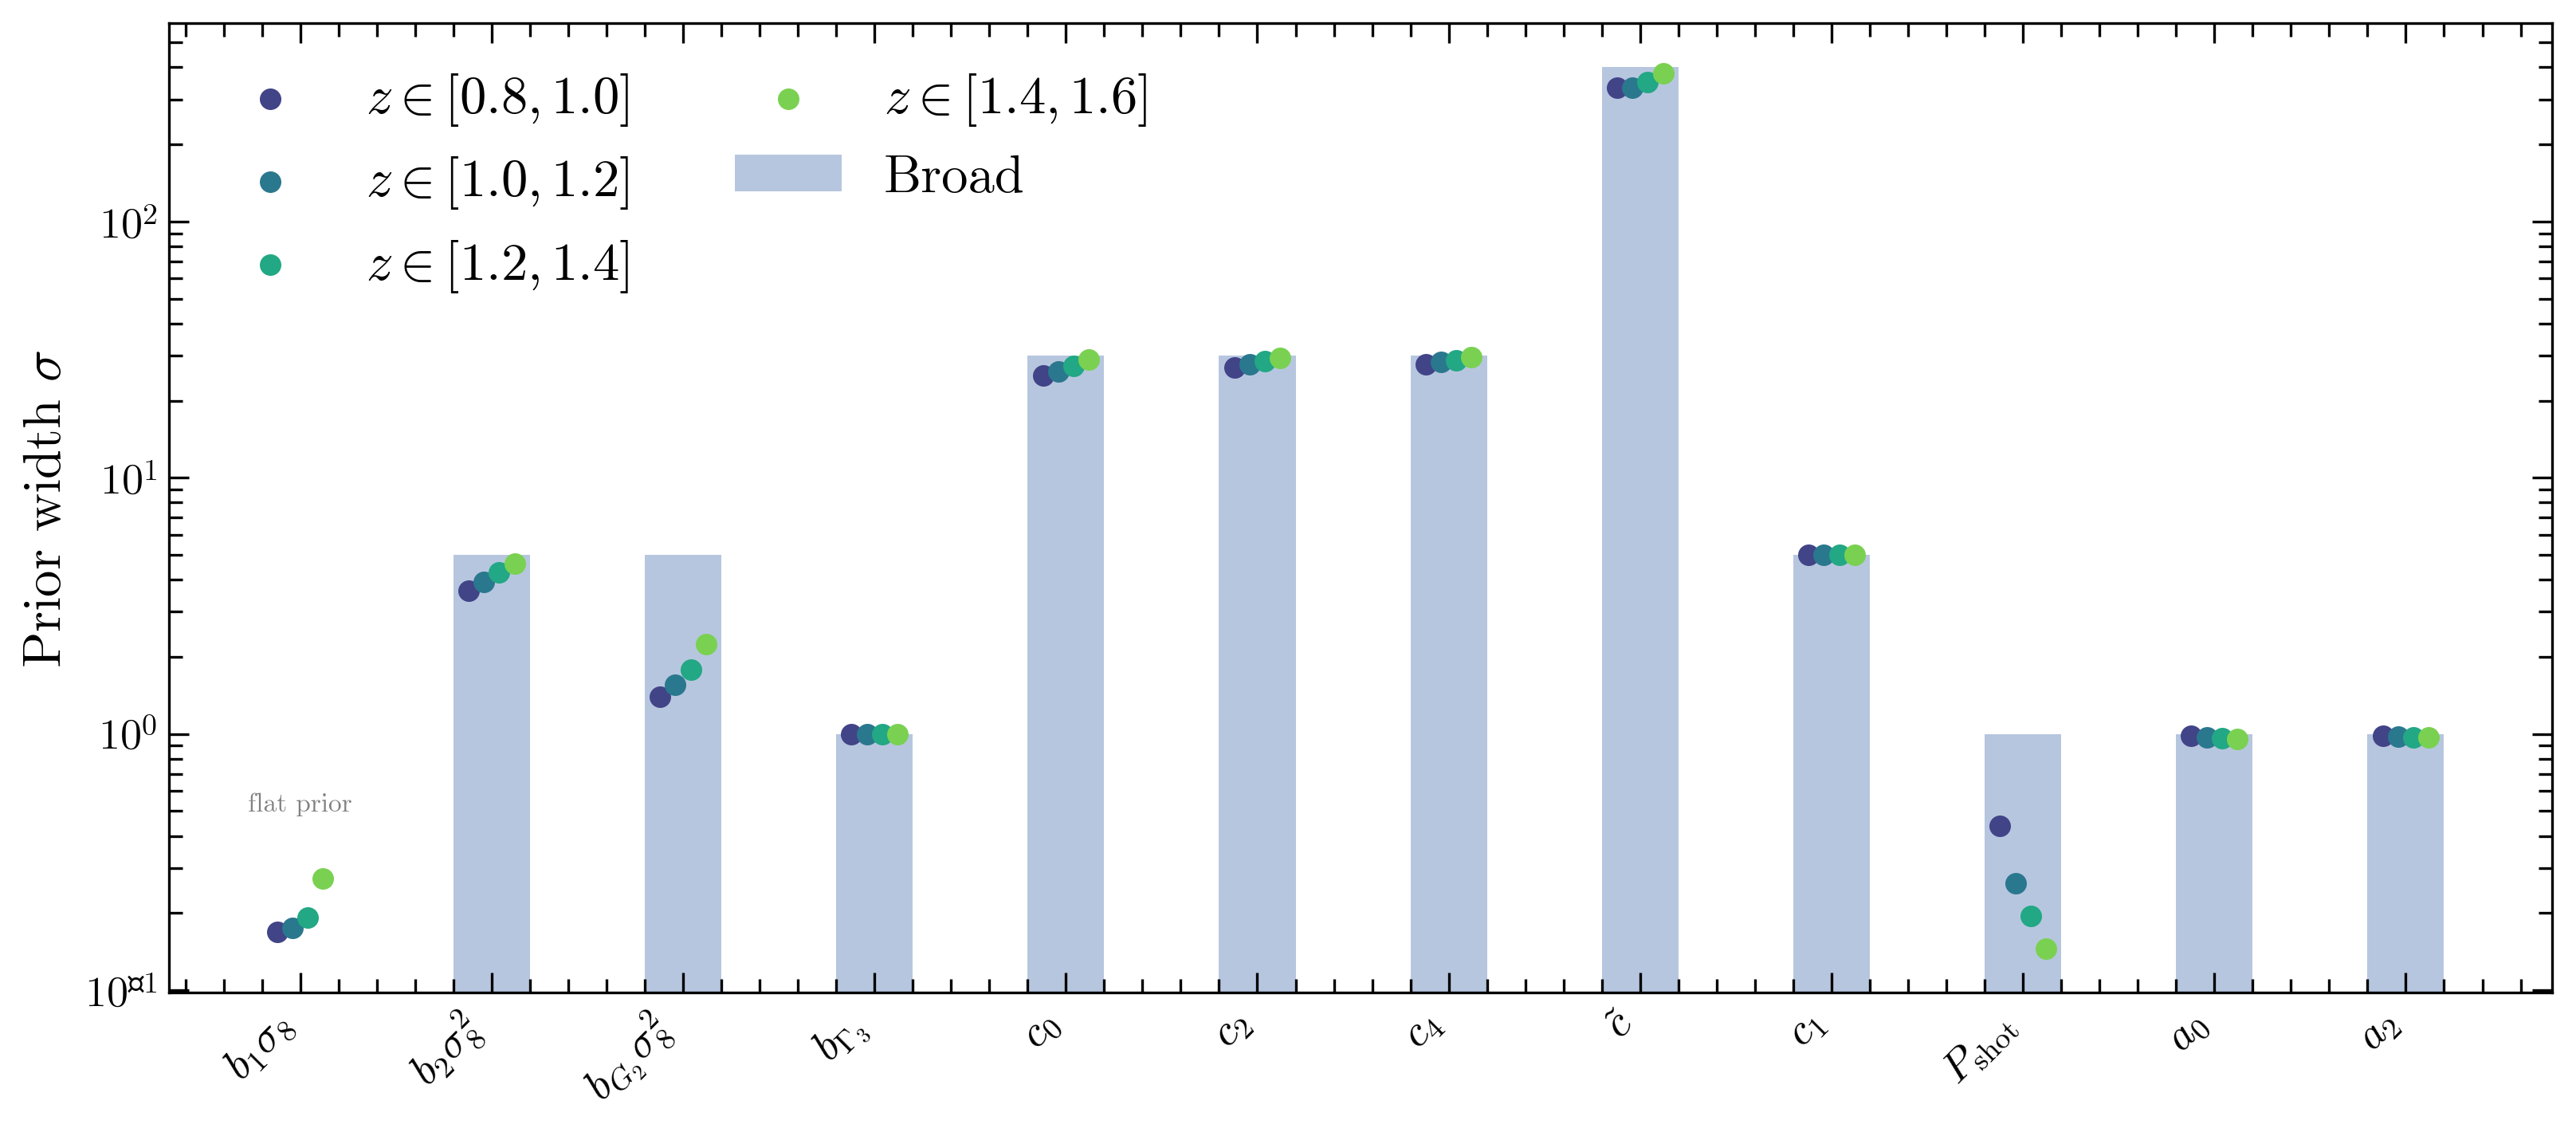

In [3]:
bp_dict = broad_priors().sigma_dict()
params_to_show = list(NUISANCE_NAMES)
plabels = {
    "b1_sigma8": r"$b_1\sigma_8$",
    "b2_sigma8sq": r"$b_2\sigma_8^2$", "bG2_sigma8sq": r"$b_{G_2}\sigma_8^2$",
    "bGamma3": r"$b_{\Gamma_3}$", "c0": r"$c_0$", "c2": r"$c_2$", "c4": r"$c_4$",
    "c_tilde": r"$\tilde{c}$", "c1": r"$c_1$",
    "Pshot": r"$P_{\rm shot}$", "a0": r"$a_0$", "a2": r"$a_2$",
}

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(params_to_show))

# Broad priors as bars (skip b1_sigma8 which has flat prior)
for i, p in enumerate(params_to_show):
    bv = bp_dict[p]
    if bv is not None:
        ax.bar(i, bv, 0.4, color="#4C72B0", alpha=0.4,
               label="Broad" if i == 1 else None)

# Calibrated priors per z-bin
colors = plt.cm.viridis(np.linspace(0.2, 0.8, len(sorted_zbins)))
for iz, zb in enumerate(sorted_zbins):
    cal = overlap[zb].calibrated_priors
    cal_vals = [cal.params.get(p, np.nan) for p in params_to_show]
    offset = (iz - len(sorted_zbins) / 2 + 0.5) * 0.08
    ax.scatter(x + offset, cal_vals, color=colors[iz], s=30, zorder=5,
               label=f"$z \\in [{zb[0]:.1f},{zb[1]:.1f}]$")

ax.set_xticks(x)
ax.set_xticklabels([plabels.get(p, p) for p in params_to_show],
                    rotation=45, ha="right")
ax.set_ylabel(r"Prior width $\sigma$")
ax.set_yscale("log")
ax.legend(frameon=False, fontsize=16, ncol=2)

# Annotate b1_sigma8 as flat prior
b1_idx = params_to_show.index("b1_sigma8")
ax.annotate("flat prior", xy=(b1_idx, 0.5), fontsize=8, ha="center",
            color="gray", style="normal")

fig.tight_layout()
plt.show()

## Figure 2 --- Full-area DESI constraints (money figure)

Bar chart of marginalized sigma(fsigma8), sigma(Mnu), sigma(Omegam)
under three scenarios. SBP benchmark lines from Zhang+ 2025 (PS-level)
and Chudaykin+ 2026 (field-level). No field-level line for Mnu because
SBPs worsen the LCDM bound (Chudaykin+ 2026, Table IV).

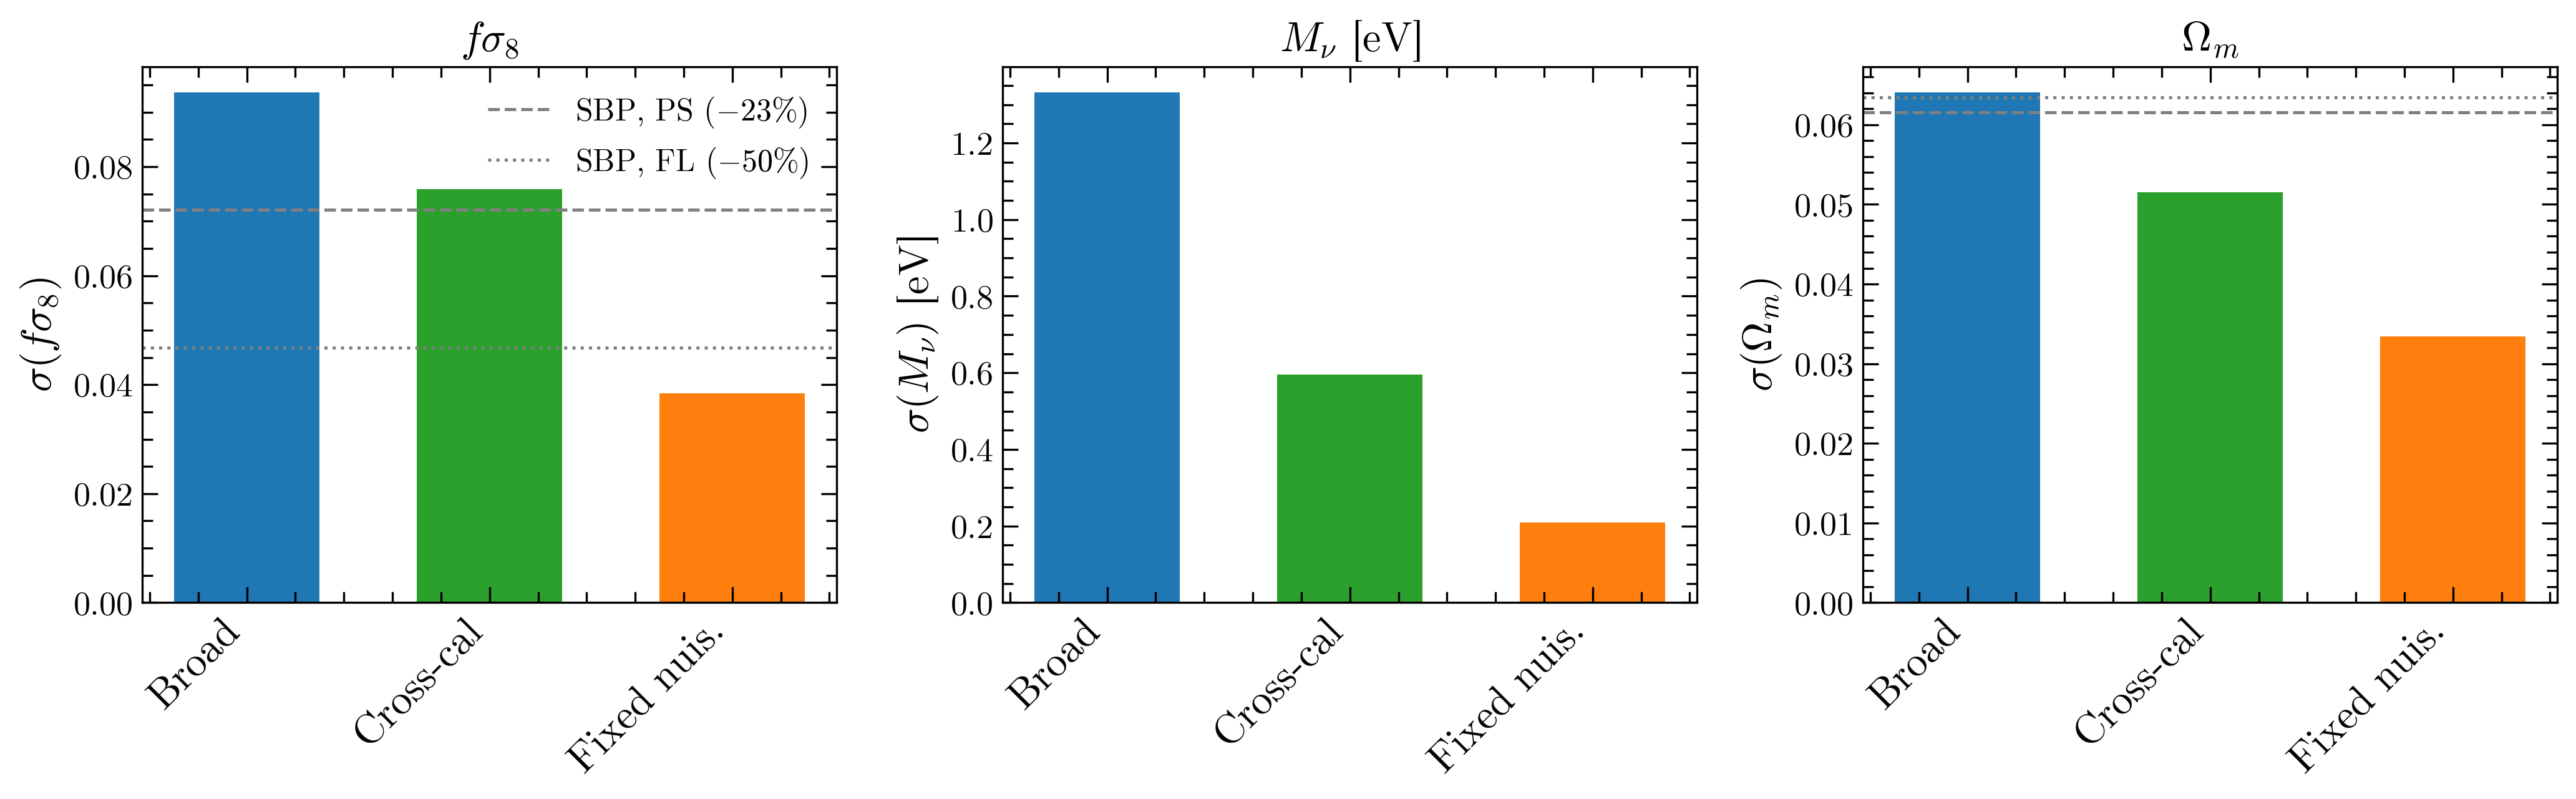


Headline numbers:
  Broad            $f\sigma_8$ : sigma = 9.3665e-02  (+0.0%)
  Broad            $M_\nu$ [eV]: sigma = 1.3325e+00  (+0.0%)
  Broad            $\Omega_m$  : sigma = 6.4089e-02  (+0.0%)
  Cross-cal        $f\sigma_8$ : sigma = 7.5864e-02  (+19.0%)
  Cross-cal        $M_\nu$ [eV]: sigma = 5.9614e-01  (+55.3%)
  Cross-cal        $\Omega_m$  : sigma = 5.1524e-02  (+19.6%)
  Fixed nuis.      $f\sigma_8$ : sigma = 3.8470e-02  (+58.9%)
  Fixed nuis.      $M_\nu$ [eV]: sigma = 2.0857e-01  (+84.3%)
  Fixed nuis.      $\Omega_m$  : sigma = 3.3417e-02  (+47.9%)


In [4]:
param_titles = [r"$f\sigma_8$", r"$M_\nu$ [eV]", r"$\Omega_m$"]
param_ylabels = [r"$\sigma(f\sigma_8)$", r"$\sigma(M_\nu)$ [eV]", r"$\sigma(\Omega_m)$"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

for ip, (cp, title, ylabel) in enumerate(zip(cosmo_params, param_titles, param_ylabels)):
    ax = axes[ip]
    x = np.arange(len(scenario_names))
    vals = [scenarios[sn].sigmas_combined[cp] for sn in scenario_names]
    colors = [COLORS[sn] for sn in scenario_names]

    ax.bar(x, vals, color=colors, width=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([LABELS[sn] for sn in scenario_names], rotation=45, ha="right", fontsize=16)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    sigma_broad = scenarios["broad"].sigmas_combined[cp]

    if cp == "fsigma8":
        hod_imp = HOD_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray",
                   lw=1.2, label=fr"SBP, PS ($-{hod_imp*100:.0f}$%)")
        fl_imp = FIELD_LEVEL_BENCHMARK["sigma8_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray",
                   lw=1.2, label=fr"SBP, FL ($-{fl_imp*100:.0f}$%)")
        ax.legend(frameon=False, loc="upper right")

    if cp == "Omegam":
        hod_imp = HOD_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - hod_imp), ls="--", color="gray", lw=1.2)
        fl_imp = FIELD_LEVEL_BENCHMARK["Omegam_improvement"]
        ax.axhline(sigma_broad * (1 - fl_imp), ls=":", color="gray", lw=1.2)

fig.tight_layout()
plt.show()

# Print headline numbers
print("\nHeadline numbers:")
sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}
for sn in scenario_names:
    for cp, label in zip(cosmo_params, param_titles):
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        print(f"  {LABELS[sn]:16s} {label:12s}: sigma = {s:.4e}  ({imp:+.1f}%)")

## Figure 3 --- Calibration efficiency per z-bin

Efficiency = (sigma_broad - sigma_xcal) / (sigma_broad - sigma_fixed).
0 = cross-cal adds nothing; 1 = achieves the fixed-nuisance limit.

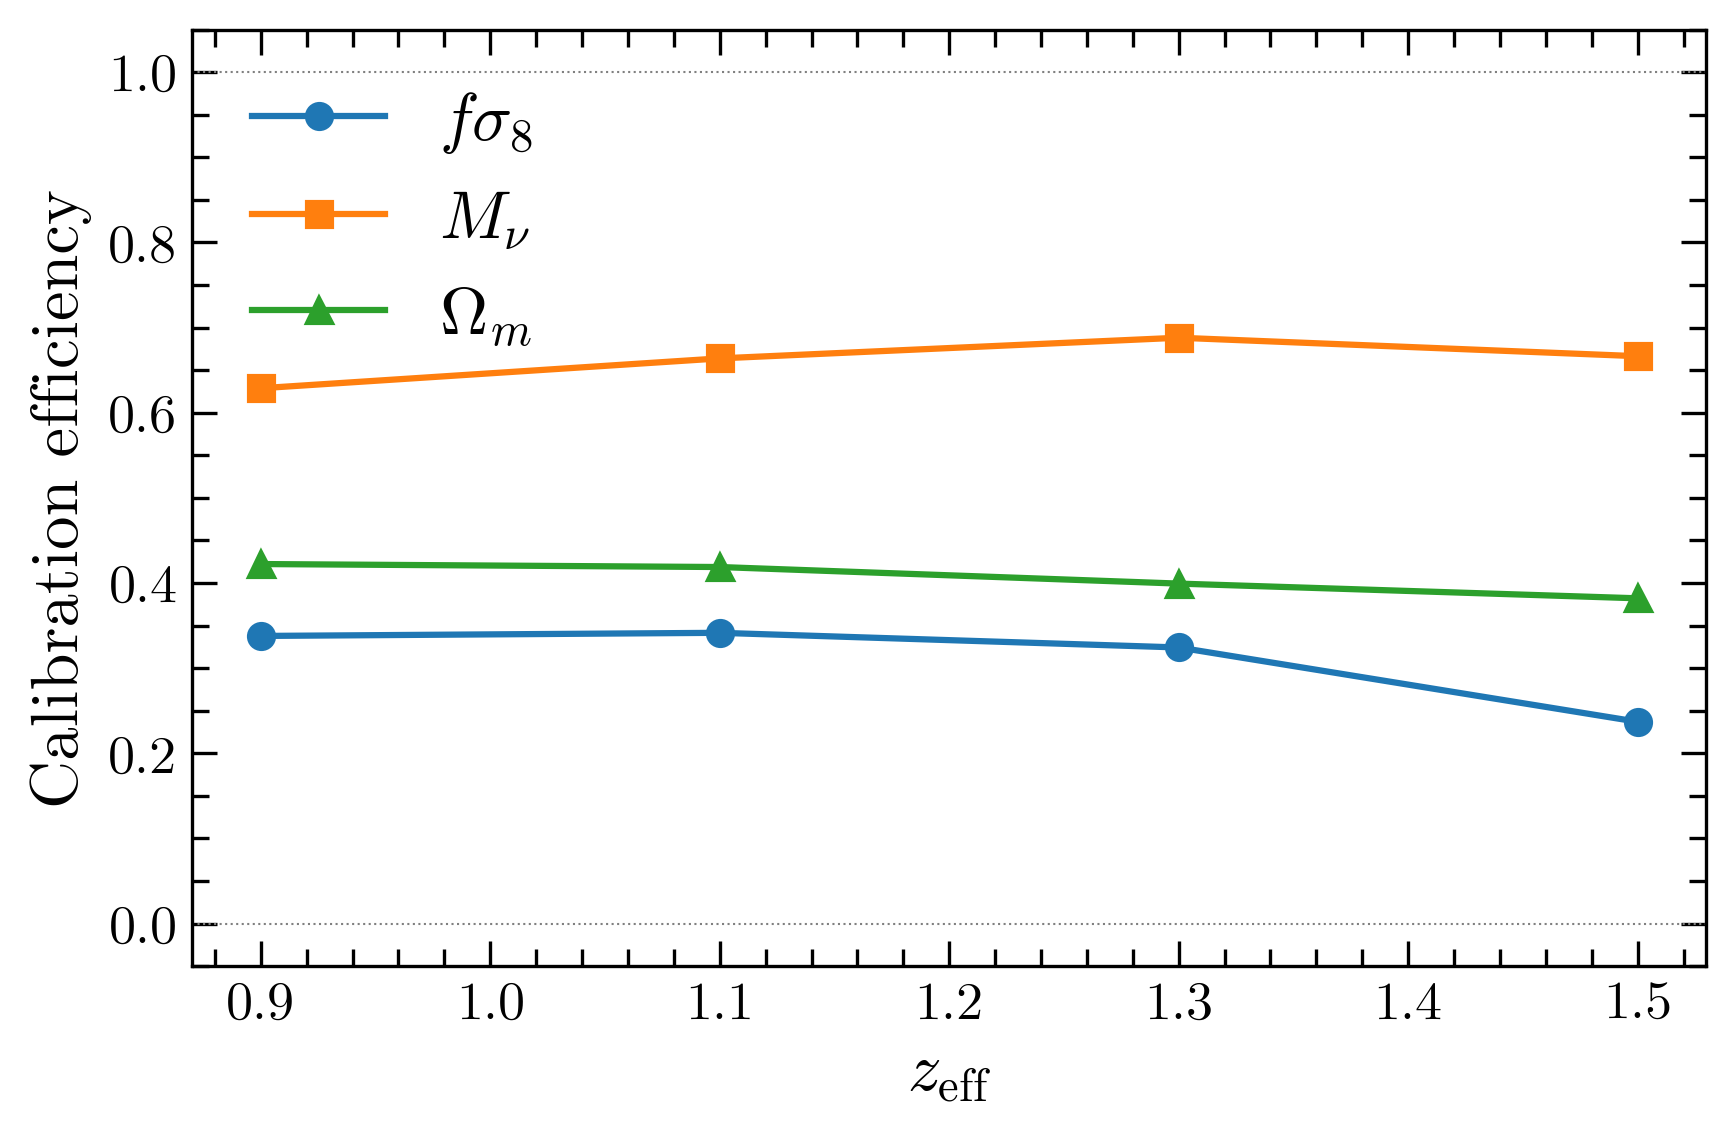

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))

markers = {"fsigma8": "o", "Mnu": "s", "Omegam": "^"}
clabels = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}
z_mids = [0.5 * (zb[0] + zb[1]) for zb in z_bins]

for cp in cosmo_params:
    effs = []
    for zb in z_bins:
        sb = scenarios["broad"].sigmas_per_z[zb][cp]
        so = scenarios["oracle"].sigmas_per_z[zb][cp]
        sx = scenarios["cross-cal"].sigmas_per_z[zb][cp]
        eff = compute_calibration_efficiency(sx, sb, so)
        effs.append(eff if eff is not None else 0.0)
    ax.plot(z_mids, effs, marker=markers[cp], label=clabels[cp], lw=1.5)

ax.set_xlabel(r"$z_{\rm eff}$")
ax.set_ylabel("Calibration efficiency")
ax.set_ylim(-0.05, 1.05)
ax.axhline(1.0, ls=":", color="gray", lw=0.5)
ax.axhline(0.0, ls=":", color="gray", lw=0.5)
ax.legend(frameon=False, fontsize=16)
fig.tight_layout()
plt.show()

## Figure 4 --- Sensitivity to r_sigma_v (two curves)

Two curves disentangle the r_sigma_v channels:
- **Asymmetric kmax** (green): kmax_PFS = kmax_DESI / r_sigma_v (default)
- **Symmetric kmax** (red): kmax_PFS = kmax_DESI = 0.20 (fixed)

The gap between the red curve and the broad baseline = gain from
multi-tracer stochastic/bias separation (independent of r_sigma_v).
The gap between green and red = additional gain from asymmetric kmax.

**This cell re-runs the pipeline for each r_sigma_v value (~30s each, ~5 min total).**

In [6]:
r_values = [0.5, 0.6, 0.75, 0.9, 1.0]
sigma_asym = {}
sigma_sym = {}
broad_baseline = None

for r in r_values:
    # Asymmetric kmax (default)
    cfg_r = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv")
    res_r = run_pipeline(cfg_r, verbose=False)
    sigma_asym[r] = res_r.scenario_results["cross-cal"].sigmas_combined["fsigma8"]
    if broad_baseline is None:
        broad_baseline = res_r.scenario_results["broad"].sigmas_combined["fsigma8"]

    # Symmetric kmax (fixed kmax_PFS = kmax_DESI)
    cfg_s = ForecastConfig(r_sigma_v=r, output_dir="results/_sweep_rsv",
                           kmax_pfs_overlap=0.20, kmax_cross_overlap=0.20)
    res_s = run_pipeline(cfg_s, verbose=False)
    sigma_sym[r] = res_s.scenario_results["cross-cal"].sigmas_combined["fsigma8"]

    imp_a = (broad_baseline - sigma_asym[r]) / broad_baseline * 100
    imp_s = (broad_baseline - sigma_sym[r]) / broad_baseline * 100
    print(f"  r_sv={r:.2f}: asym={sigma_asym[r]:.4e} ({imp_a:+.1f}%)  "
          f"sym={sigma_sym[r]:.4e} ({imp_s:+.1f}%)")

  r_sv=0.50: asym=7.2100e-02 (+23.0%)  sym=7.7356e-02 (+17.4%)
  r_sv=0.60: asym=7.3620e-02 (+21.4%)  sym=7.7353e-02 (+17.4%)
  r_sv=0.75: asym=7.5864e-02 (+19.0%)  sym=7.7342e-02 (+17.4%)
  r_sv=0.90: asym=7.6976e-02 (+17.8%)  sym=7.7321e-02 (+17.4%)
  r_sv=1.00: asym=7.7296e-02 (+17.5%)  sym=7.7296e-02 (+17.5%)


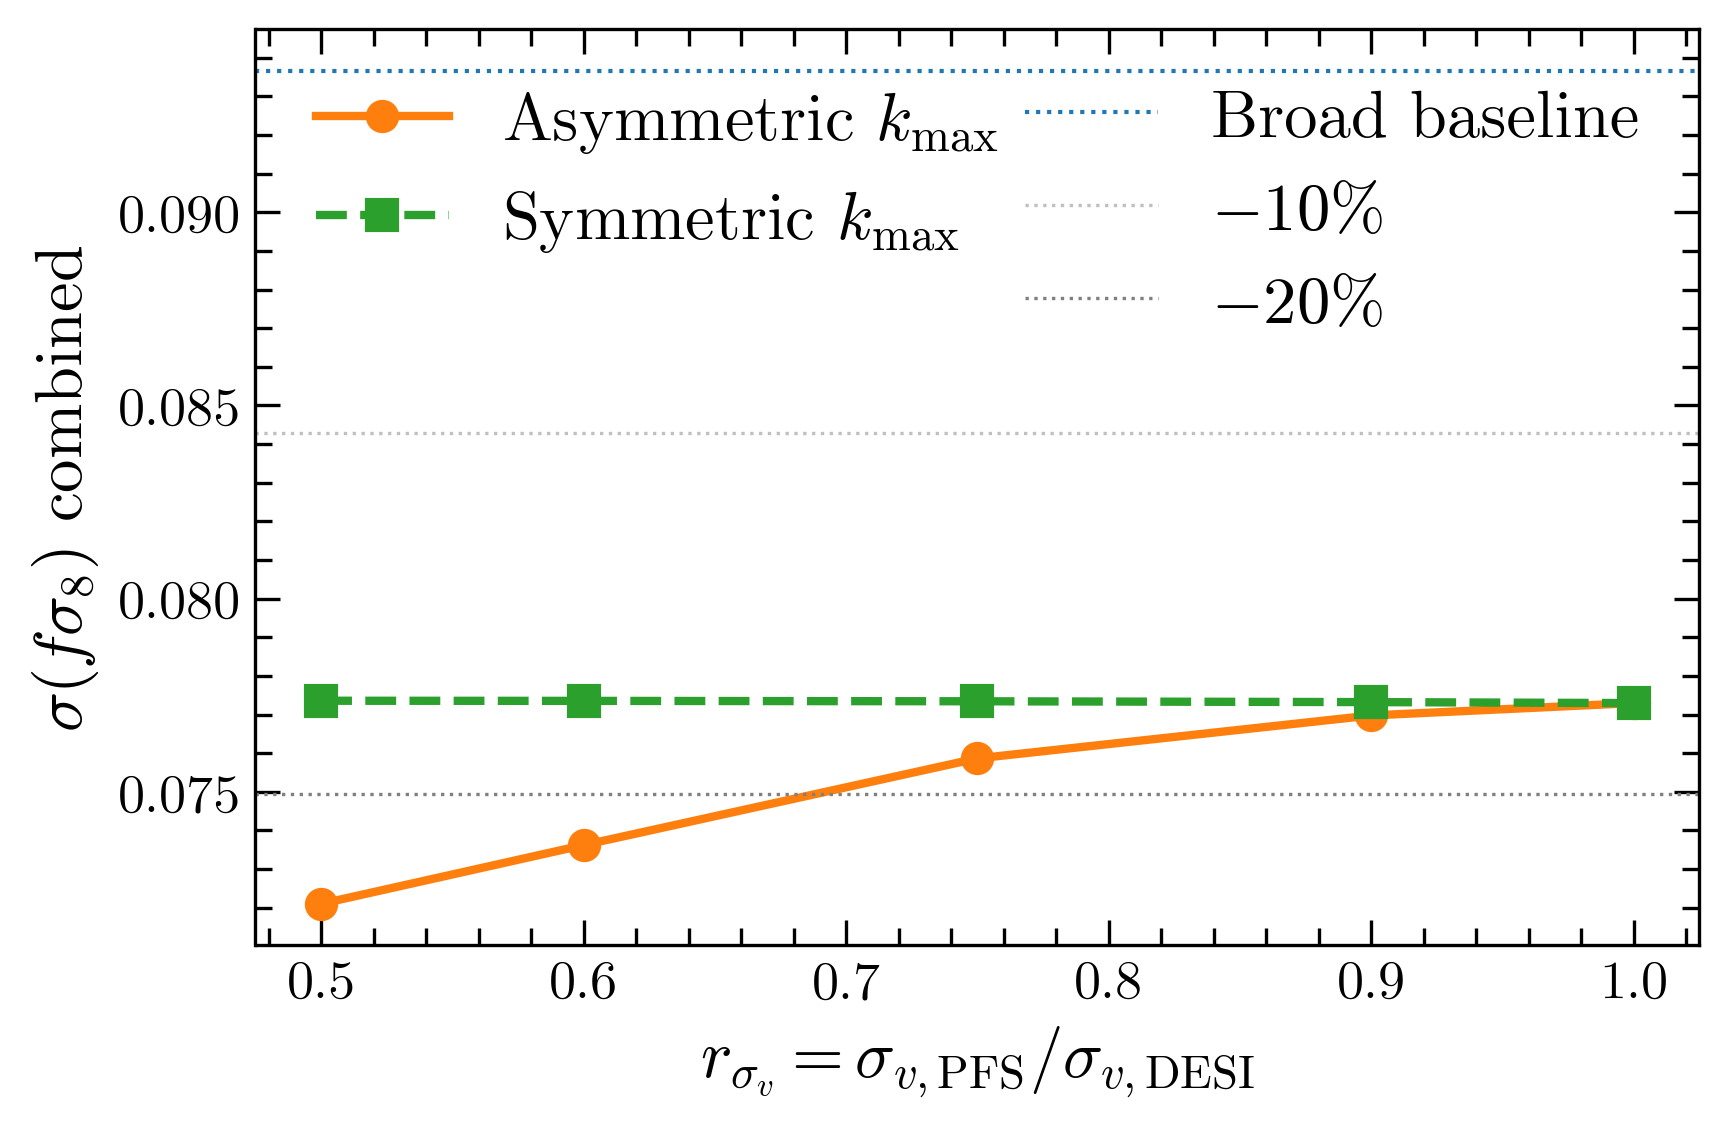

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))

r_arr = sorted(sigma_asym.keys())
h1, = ax.plot(r_arr, [sigma_asym[r] for r in r_arr], "o-", color="C1",
              lw=2, ms=7, label=r"Asymmetric $k_{\max}$")
h2, = ax.plot(r_arr, [sigma_sym[r] for r in r_arr], "s--", color="C2",
              lw=2, ms=7, label=r"Symmetric $k_{\max}$")

h3 = ax.axhline(broad_baseline, ls=":", color="C0", lw=1, label="Broad baseline")
c = ['silver', 'gray']
h4 = ax.axhline(broad_baseline * 0.9, ls=':', color=c[0], lw=0.8, label=r"$-10$%")
h5 = ax.axhline(broad_baseline * 0.8, ls=':', color=c[1], lw=0.8, label=r"$-20$%")

ax.set_xlabel(r"$r_{\sigma_v} = \sigma_{v,\mathrm{PFS}} / \sigma_{v,\mathrm{DESI}}$")
ax.set_ylabel(r"$\sigma(f\sigma_8)$ combined")

leg1 = ax.legend(
    [h1, h2],
    [r"Asymmetric $k_{\max}$", r"Symmetric $k_{\max}$"],
    frameon=False,
    loc="upper left",
    fontsize=16,
    bbox_to_anchor=(0., 1.00),
)

ax.add_artist(leg1)

leg2 = ax.legend(
    [h3, h4, h5],
    ["Broad baseline", r"$-10$%", r"$-20$%"],
    frameon=False,
    loc="upper right",
    fontsize=16,
    bbox_to_anchor=(1.00, 1.00),
)

fig.tight_layout()
plt.show()

## Summary table

In [8]:
print(f"{'Scenario':<18s} {'kmax':>5s}  {'sigma(fs8)':>10s}  {'D%':>6s}  "
      f"{'sigma(Mnu)':>10s}  {'D%':>6s}  {'sigma(Om)':>10s}  {'D%':>6s}")
print("-" * 85)

sb = {cp: scenarios["broad"].sigmas_combined[cp] for cp in cosmo_params}

for sn in scenario_names:
    sc = [s for s in SCENARIOS if s.name == sn][0]
    row = f"{LABELS[sn]:<18s} {sc.kmax:5.2f}"
    for cp in cosmo_params:
        s = scenarios[sn].sigmas_combined[cp]
        imp = (sb[cp] - s) / sb[cp] * 100
        row += f"  {s:10.4e}  {imp:+5.1f}%"
    print(row)

print()
print(f"kmax_DESI = {cfg.kmax_desi_overlap:.3f}, "
      f"kmax_PFS = {cfg.compute_kmax_pfs():.3f} h/Mpc  "
      f"(r_sv = {cfg.r_sigma_v})")
print(f"f_shared = {cfg.f_shared_elg}")
print(f"Overlap: {cfg.overlap_area_deg2:.0f} deg^2, "
      f"Full DESI: {cfg.desi_area_deg2:.0f} deg^2")
print(f"z-bins: {z_bins}")

Scenario            kmax  sigma(fs8)      D%  sigma(Mnu)      D%   sigma(Om)      D%
-------------------------------------------------------------------------------------
Broad               0.20  9.3665e-02   +0.0%  1.3325e+00   +0.0%  6.4089e-02   +0.0%
Cross-cal           0.20  7.5864e-02  +19.0%  5.9614e-01  +55.3%  5.1524e-02  +19.6%
Fixed nuis.         0.20  3.8470e-02  +58.9%  2.0857e-01  +84.3%  3.3417e-02  +47.9%

kmax_DESI = 0.200, kmax_PFS = 0.267 h/Mpc  (r_sv = 0.75)
f_shared = 0.045
Overlap: 1200 deg^2, Full DESI: 14000 deg^2
z-bins: [(0.8, 1.0), (1.0, 1.2), (1.2, 1.4), (1.4, 1.6)]


## Appendix Figure A1 --- Derivative validation (autodiff vs stencil)

Compares JAX forward-mode autodiff against a 5-point central-difference
stencil for b1*sigma8, c2, and c_tilde across k for ell=0,2.
Grey band = +/-10%.

In [ ]:
import jax.numpy as jnp
from ps_1loop_jax import PowerSpectrum1Loop
from pfsfog.cosmo import FiducialCosmology
from pfsfog.eft_params import desi_elg_fiducials, COSMO_NAMES
from pfsfog.ps1loop_adapter import fisher_to_ps1loop_auto
from pfsfog.derivatives import (
    dPell_dtheta_autodiff, dPell_dtheta_stencil,
    dPell_d_fsigma8, dPell_d_cosmo_stencil,
)

ps = PowerSpectrum1Loop(do_irres=False)
cosmo_d = FiducialCosmology(backend="cosmopower")
z_eff = 0.9
s8 = cosmo_d.sigma8(z_eff); f_z = float(cosmo_d.f(z_eff)); h_d = cosmo_d.params["h"]
pk_data = cosmo_d.pk_data(z_eff)
b1_d, nbar_d = 1.3, 4e-4
fid = desi_elg_fiducials(b1_d, s8)
params_d = fisher_to_ps1loop_auto(fid, s8, f_z, h_d, nbar_d)
k_deriv = jnp.arange(0.01, 0.26, 0.005)
k_np = np.asarray(k_deriv)
P0_fid = np.asarray(ps.get_pk_ell(k_deriv, 0, pk_data, params_d))

# All derivatives (monopole)
cosmo_derivs_d = {
    "fsigma8": np.asarray(dPell_d_fsigma8(ps, k_deriv, pk_data, params_d, s8, 0)),
}
for cp in ("Omegam", "Mnu"):
    cosmo_derivs_d[cp] = np.asarray(dPell_d_cosmo_stencil(
        ps, k_deriv, cosmo_d, params_d, cp, z_eff, s8, 0))

nuis_ad, nuis_st = {}, {}
for pn in NUISANCE_NAMES:
    nuis_ad[pn] = np.asarray(dPell_dtheta_autodiff(ps, k_deriv, pk_data, params_d, pn, s8, 0))
    nuis_st[pn] = np.asarray(dPell_dtheta_stencil(ps, k_deriv, pk_data, params_d, pn, s8, 0))

# Plot
GROUPS = {
    "Cosmo": (["fsigma8","Mnu","Omegam"],
              [r"$f\sigma_8$",r"$M_\nu$",r"$\Omega_m$"],
              ["#E24A33","#348ABD","#988ED5"]),
    "Bias": (["b1_sigma8","b2_sigma8sq","bG2_sigma8sq","bGamma3"],
             [r"$b_1\sigma_8$",r"$b_2\sigma_8^2$",r"$b_{G_2}\sigma_8^2$",r"$b_{\Gamma_3}$"],
             ["#2ca02c","#98df8a","#006400","#90EE90"]),
    "Ctr": (["c0","c2","c4","c_tilde","c1"],
            [r"$c_0$",r"$c_2$",r"$c_4$",r"$\tilde{c}$",r"$c_1$"],
            ["#ff7f0e","#ffbb78","#d62728","#ff9896","#bcbd22"]),
    "Stoch": (["Pshot","a0","a2"],
              [r"$P_{\rm shot}$",r"$a_0$",r"$a_2$"],
              ["#17becf","#9edae5","#7f7f7f"]),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for gn, (pnames, labels, colors) in GROUPS.items():
    for pn, lab, col in zip(pnames, labels, colors):
        d = cosmo_derivs_d.get(pn, nuis_ad.get(pn))
        if d is None: continue
        nd = np.abs(d) / np.abs(P0_fid)
        if np.max(nd) < 1e-10: continue
        ax1.semilogy(k_np, nd, lw=1.3, color=col, label=lab)

ax1.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
ax1.set_ylabel(r"$|\partial P_0 / \partial \theta_i| / P_0$")
ax1.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")
ax1.set_title("Derivative landscape")

for gn, (pnames, labels, colors) in GROUPS.items():
    if gn == "Cosmo": continue
    for pn, lab, col in zip(pnames, labels, colors):
        ad, st = nuis_ad.get(pn), nuis_st.get(pn)
        if ad is None: continue
        scale = np.maximum(np.abs(ad), np.abs(st))
        mask = scale > 1e-10 * np.max(scale)
        frac = np.full_like(ad, np.nan)
        frac[mask] = np.abs(ad[mask] - st[mask]) / scale[mask]
        if np.all(np.isnan(frac)) or np.nanmax(frac) < 1e-15: continue
        ax2.semilogy(k_np, frac, lw=1.0, color=col, label=lab, alpha=0.8)

ax2.axhline(1e-9, ls=":", color="gray", lw=0.8, label=r"$10^{-9}$")
ax2.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]")
ax2.set_ylabel(r"|autodiff $-$ stencil| / |max|")
ax2.set_ylim(1e-12, 1e-6)
ax2.legend(frameon=False, fontsize=8, ncol=2, loc="upper right")
ax2.set_title("Autodiff vs. stencil agreement")
fig.tight_layout()
plt.show()

## Appendix Figure A2 --- McDonald-Seljak convergence

Single-tracer vs multi-tracer sigma^2(Pm)/Pm^2 as a function of nbar.
The multi-tracer curve converges to the cosmic-variance-free floor
2/N_modes; the single-tracer plateaus above it due to the b-f degeneracy.

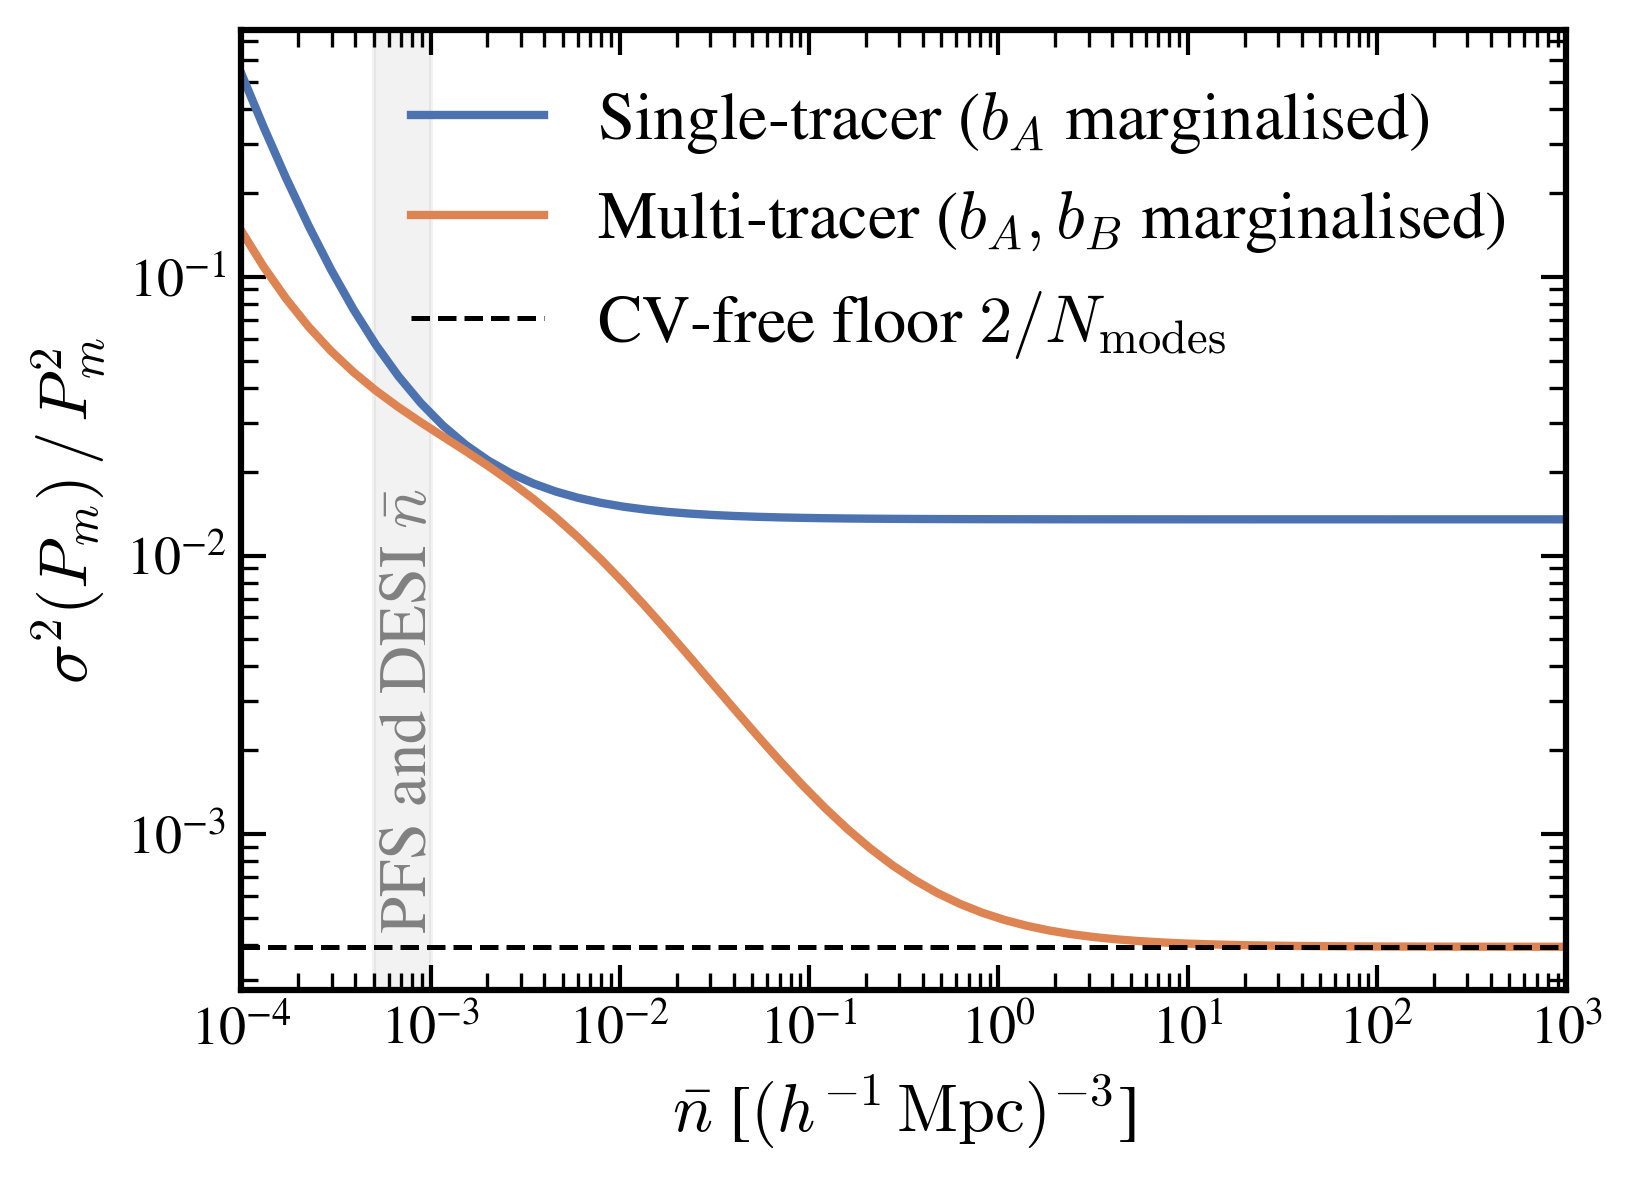

In [42]:
from numpy.polynomial.legendre import leggauss

bA, bB, f_ms, Pm = 1.0, 2.0, 0.8, 1e3  # Pm ~ P(k=0.1) in (Mpc/h)^3
k_ms, dk_ms, V_ms = 0.1, 0.01, 1e9
Nmodes_ms = k_ms**2 * dk_ms * V_ms / (2 * np.pi**2)
mu_gl, w_gl = leggauss(40)

def _sigma2_st(nbar):
    F = np.zeros((2, 2))
    for mi, wi in zip(mu_gl, w_gl):
        sA = bA + f_ms * mi**2
        PAA = sA**2 * Pm + 1.0 / nbar
        D = np.array([sA**2, 2.0 * sA * Pm])
        F += wi * np.outer(D, D) / (2.0 * PAA**2)
    F *= Nmodes_ms / 2.0
    return 1.0 / (F[0, 0] - F[0, 1]**2 / F[1, 1])

def _sigma2_mt(nbar):
    F = np.zeros((3, 3))
    for mi, wi in zip(mu_gl, w_gl):
        sA = bA + f_ms * mi**2
        sB = bB + f_ms * mi**2
        PAA = sA**2 * Pm + 1.0 / nbar
        PBB = sB**2 * Pm + 1.0 / nbar
        PAB = sA * sB * Pm
        C3 = np.array([
            [2*PAA**2,     2*PAB**2,        2*PAA*PAB],
            [2*PAB**2,     2*PBB**2,        2*PBB*PAB],
            [2*PAA*PAB,    2*PBB*PAB,       PAA*PBB + PAB**2]])
        D = np.array([
            [sA**2,   2*sA*Pm, 0.0],
            [sB**2,   0.0,     2*sB*Pm],
            [sA*sB,   sB*Pm,   sA*Pm]])
        F += wi * D.T @ np.linalg.inv(C3) @ D
    F *= Nmodes_ms / 2.0
    Fb = F[1:, 1:]
    Fc = F[0, 1:]
    return 1.0 / (F[0, 0] - Fc @ np.linalg.solve(Fb, Fc))

nbars_ms = np.logspace(-4, 3, 60)  # 1e-4 to 1e3: covers realistic survey densities
s2_st = np.array([_sigma2_st(n) for n in nbars_ms])
s2_mt = np.array([_sigma2_mt(n) for n in nbars_ms])
cv_floor = 2.0 * Pm**2 / Nmodes_ms

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(nbars_ms, s2_st / Pm**2, "-", color="#4C72B0", lw=2,
          label=r"Single-tracer ($b_A$ marginalised)")
ax.loglog(nbars_ms, s2_mt / Pm**2, "-", color="#DD8452", lw=2,
          label=r"Multi-tracer ($b_A, b_B$ marginalised)")
ax.axhline(cv_floor / Pm**2, ls="--", color="k", lw=1.2,
           label=r"CV-free floor $2/N_{\rm modes}$")

# Typical survey nbar range
ax.axvspan(5e-4, 1e-3, color="gray", alpha=0.10, zorder=0)
ax.text(7.8e-4, 5e-4, r"PFS and DESI $\bar{n}$", color="gray",
        fontsize=16, ha="center", rotation=90)

ax.set_xlabel(r"$\bar{n}$ [$(h^{-1}\,\mathrm{Mpc})^{-3}$]")
ax.set_ylabel(r"$\sigma^2(P_m)\,/\,P_m^2$")
ax.set_xlim(nbars_ms[0], nbars_ms[-1])
ax.legend(frameon=False, fontsize=16, loc="upper right")
fig.tight_layout()
plt.show()

## Appendix Figure A3 --- Fisher information density

Conditional vs marginalized Fisher information density dF_ii/dk for
fσ₈, Mν, Ωm. The gap between the two curves shows how much
information is lost to nuisance marginalization at each k.

In [ ]:
from pfsfog.derivatives import dPell_dtheta_autodiff_all, dPell_d_cosmo_all
from pfsfog.covariance import single_tracer_cov
from pfsfog.fisher_full_area import full_area_fisher_per_zbin
from pfsfog.surveys import desi_elg as make_desi_elg
from pfsfog.eft_params import COSMO_PRIOR_SIGMA

desi_fi = make_desi_elg()
ells_fi = (0,2,4); kmax_fi = 0.20
k_fi = np.arange(cfg.kmin, kmax_fi + cfg.dk/2, cfg.dk)
zlo_fi, zhi_fi = 0.8, 1.0
z_fi = 0.9
s8_fi = cosmo_d.sigma8(z_fi); f_fi = float(cosmo_d.f(z_fi))
nbar_fi = desi_fi.nbar_eff(zlo_fi, zhi_fi)
b1_fi = desi_fi.b1_of_z(z_fi); V_fi = desi_fi.volume(zlo_fi, zhi_fi)
pk_fi = cosmo_d.pk_data(z_fi)
fid_fi = desi_elg_fiducials(b1_fi, s8_fi)
par_fi = fisher_to_ps1loop_auto(fid_fi, s8_fi, f_fi, cosmo_d.params["h"], nbar_fi)

derivs_fi = dPell_dtheta_autodiff_all(ps, jnp.array(k_fi), pk_fi, par_fi, NUISANCE_NAMES, s8_fi, ells_fi)
derivs_fi.update(dPell_d_cosmo_all(ps, jnp.array(k_fi), pk_fi, cosmo_d, par_fi, z_fi, s8_fi, ells_fi))
pkmu_fi = make_ps1loop_pkmu_func(ps, pk_fi, par_fi)
cov_fi = single_tracer_cov(pkmu_fi, k_fi, nbar_fi, V_fi, cfg.dk, ells_fi)

N_C = len(COSMO_NAMES); N_N = len(NUISANCE_NAMES); Np = N_C + N_N
Nk = len(k_fi); Nell = len(ells_fi)
D_fi = np.zeros((Nk, Nell, Np))
for ic, cn in enumerate(COSMO_NAMES):
    for il, ell in enumerate(ells_fi):
        if cn in derivs_fi and ell in derivs_fi[cn]:
            D_fi[:,il,ic] = np.asarray(derivs_fi[cn][ell])
for ip, nn in enumerate(NUISANCE_NAMES):
    for il, ell in enumerate(ells_fi):
        if nn in derivs_fi and ell in derivs_fi[nn]:
            D_fi[:,il,N_C+ip] = np.asarray(derivs_fi[nn][ell])

info_cond = {cn: np.zeros(Nk) for cn in COSMO_NAMES}
info_marg = {cn: np.zeros(Nk) for cn in COSMO_NAMES}

for ik in range(Nk):
    ci = np.linalg.inv(cov_fi[ik])
    Fk = D_fi[ik].T @ ci @ D_fi[ik]
    for ic, cn in enumerate(COSMO_NAMES):
        info_cond[cn][ik] = Fk[ic, ic]

bp_d = broad_priors().prior_fisher_diag()
pf = np.zeros(Np); pf[N_C:] = bp_d
for i, cn in enumerate(COSMO_NAMES):
    pf[i] = 1.0 / COSMO_PRIOR_SIGMA[cn]**2
F_cum = np.diag(pf).copy()
prev = {cn: pf[i] for i, cn in enumerate(COSMO_NAMES)}
for ik in range(Nk):
    ci = np.linalg.inv(cov_fi[ik])
    F_cum += D_fi[ik].T @ ci @ D_fi[ik] * cfg.dk
    try:
        C_cum = np.linalg.inv(F_cum)
        for ic, cn in enumerate(COSMO_NAMES):
            mf = 1.0 / C_cum[ic,ic]
            info_marg[cn][ik] = (mf - prev[cn]) / cfg.dk
            prev[cn] = mf
    except: pass

clabels_fi = {"fsigma8": r"$f\sigma_8$", "Mnu": r"$M_\nu$", "Omegam": r"$\Omega_m$"}
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ic, (cn, ax) in enumerate(zip(COSMO_NAMES, axes)):
    ax.semilogy(k_fi, info_cond[cn], "-", color="#4C72B0", lw=2, label="Conditional")
    ax.semilogy(k_fi, np.maximum(info_marg[cn], 1e-10), "-", color="#DD8452", lw=2, label="Marginalized")
    ax.set_xlabel(r"$k$ [$h\,\mathrm{Mpc}^{-1}$]"); ax.set_title(clabels_fi[cn])
    if ic == 0: ax.set_ylabel(r"$\mathrm{d}F_{ii}/\mathrm{d}k$"); ax.legend(frameon=False, fontsize=10)
fig.tight_layout()
plt.show()

## Fisher contour plot --- b1-f degeneracy visualization

2D Fisher ellipses (1σ and 2σ) for broad vs cross-cal priors.
Three panels show the key degeneracies: b₁σ₈–Mν (dominant),
b₁σ₈–fσ₈, and fσ₈–Mν (marginalized cosmological contour).
Uses the combined 4-z-bin single-ELG Fisher for visualization.

In [ ]:
from matplotlib.patches import Ellipse
from pfsfog.eft_params import desi_elg_fiducials
from pfsfog.ps1loop_adapter import fisher_to_ps1loop_auto, make_ps1loop_pkmu_func
from pfsfog.derivatives import dPell_dtheta_autodiff_all, dPell_d_cosmo_all
from pfsfog.covariance import single_tracer_cov
from pfsfog.fisher_full_area import full_area_fisher_per_zbin, combine_zbins
from pfsfog.surveys import desi_elg as make_desi_elg
from pfsfog.prior_export import calibrated_prior_fisher_diag
from pfsfog.cosmo import FiducialCosmology

cosmo_fc = FiducialCosmology(backend="cosmopower")
from ps_1loop_jax import PowerSpectrum1Loop
ps_fc = PowerSpectrum1Loop(do_irres=False)
ells_fc = (0, 2, 4); kmax_fc = 0.20
k_fc = np.arange(cfg.kmin, kmax_fc + cfg.dk / 2, cfg.dk)
desi_fc = make_desi_elg()

def build_fisher(scenario):
    fishers = []
    for zlo, zhi in z_bins:
        z_eff = 0.5 * (zlo + zhi)
        s8 = cosmo_fc.sigma8(z_eff); f_z = float(cosmo_fc.f(z_eff)); h = cosmo_fc.params["h"]
        nbar = desi_fc.nbar_eff(zlo, zhi)
        if nbar == 0: continue
        b1 = desi_fc.b1_of_z(z_eff); V = desi_fc.volume(zlo, zhi)
        pk_data = cosmo_fc.pk_data(z_eff)
        fid = desi_elg_fiducials(b1, s8)
        params = fisher_to_ps1loop_auto(fid, s8, f_z, h, nbar)
        derivs = dPell_dtheta_autodiff_all(ps_fc, jnp.array(k_fc), pk_data, params, NUISANCE_NAMES, s8, ells_fc)
        derivs.update(dPell_d_cosmo_all(ps_fc, jnp.array(k_fc), pk_data, cosmo_fc, params, z_eff, s8, ells_fc))
        pkmu = make_ps1loop_pkmu_func(ps_fc, pk_data, params)
        cov = single_tracer_cov(pkmu, k_fc, nbar, V, cfg.dk, ells_fc)
        if scenario == "broad":
            npd = broad_priors().prior_fisher_diag()
        else:
            ov = overlap.get((zlo, zhi))
            npd = calibrated_prior_fisher_diag(ov.calibrated_priors) if ov else broad_priors().prior_fisher_diag()
        fishers.append(full_area_fisher_per_zbin(derivs, cov, k_fc, cfg.dk, npd, (zlo, zhi), kmax_fc, ells_fc))
    return combine_zbins(fishers, z_bins)

fr_b = build_fisher("broad"); fr_c = build_fisher("cross-cal")
Cb = np.linalg.inv(fr_b.F); Cc = np.linalg.inv(fr_c.F)
pn = fr_b.param_names
i_f = pn.index("fsigma8"); i_m = pn.index("Mnu"); i_b = pn.index("b1_sigma8_z0.8_1.0")
xf = float(cosmo_fc.f(0.9)) * cosmo_fc.sigma8(0.9); xm = 0.06
xb = desi_fc.b1_of_z(0.9) * cosmo_fc.sigma8(0.9)

panels = [
    (i_b, i_m, r"$b_1\sigma_8\;(z{=}0.9)$", r"$M_\nu$ [eV]", xb, xm),
    (i_b, i_f, r"$b_1\sigma_8\;(z{=}0.9)$", r"$f\sigma_8$", xb, xf),
    (i_f, i_m, r"$f\sigma_8$", r"$M_\nu$ [eV]", xf, xm),
]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, (ix, iy, xl, yl, xc, yc) in zip(axes, panels):
    for C, col, lab in [(Cb, "#4C72B0", "Broad"), (Cc, "#55A868", "Cross-cal")]:
        c2 = np.array([[C[ix, ix], C[ix, iy]], [C[iy, ix], C[iy, iy]]])
        vals, vecs = np.linalg.eigh(c2)
        vals = np.maximum(vals, 1e-30)
        ang = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        for ns, al in [(1, 0.35), (2, 0.12)]:
            e = Ellipse(xy=(xc, yc), width=2*ns*np.sqrt(vals[0]),
                        height=2*ns*np.sqrt(vals[1]), angle=ang,
                        fill=True, facecolor=col, alpha=al,
                        edgecolor=col, linewidth=1.5)
            ax.add_patch(e)
        ax.plot([], [], color=col, lw=2, label=lab)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.autoscale_view()
    x1, x2 = ax.get_xlim(); y1, y2 = ax.get_ylim()
    dx = (x2 - x1) * 0.15; dy = (y2 - y1) * 0.15
    ax.set_xlim(x1 - dx, x2 + dx); ax.set_ylim(y1 - dy, y2 + dy)
    ax.plot(xc, yc, "+", color="k", ms=8, mew=1.5)
axes[0].legend(frameon=False, fontsize=12, loc="upper right")
fig.tight_layout()
plt.show()